# Homework 03


## Part 1 - Questions

### Question 1: 

Which category has more kinds of products, vegetables or fruits?

* Who (population): All vegetables and fruits in the dataset  
* What (subject, discipline): Vegetables, Fruits
* Where (location): Farms all over the United States
* When (snapshot, longitudinal): snapshot
* How much data do you need to do the analysis/work: all rows where category = "Fruits" or "Vegetables"
  
### Question 2: 

Which state has the most dairy products sold?

* Who (population): All farms that sold dairy products
* What (subject, discipline): Dairy products
* Where (location): Farms all over the United States
* When (snapshot, longitudinal): snapshot
* How much data do you need to do the analysis/work: all rows where category = "Dairy"

### Who Might Collect Relevant Data / What Articles or Publications Cite a Relevant Data Set?

Agricultural departments, food and agriculture organizations, and academic institutions may need the data set to investigate market trends in agricultural products.

## Part 2 - Selecting a Data Set, Adding Documentation



1. Name / Title: Agricultural Products Sales Data(AgricultureData.csv) 
2. Link to Data: https://www.kaggle.com/datasets/kdstoys/agricultural-products-sales-data-2022-2023
3. Source / Origin: 
	* Author or Creator: KDS Toys on Kaggle
	* Publication Date: September 2, 2024
	* Publisher: KDS Toys on Kaggle
	* Version or Data Accessed: Version 1
4. License: MIT
5. Can You Use this Data Set for Your Intended Use Case? Yes, this dataset provides information about farm sales in different states with different types of products, which is sufficient to answer my questions.

## Format




### Overview

* Format: csv
* Size: 246 KB
* Number of Records: 8893



### Sample of Data




In [6]:
import csv

#When I put the csv file in raw, it does not work. 
#So I put it under src.
with open('AgricultureData.csv', 'r') as f:
    reader = csv.reader(f)
    header = next(reader)
    
    for i, row in enumerate(reader):
        if i < 5: 
            print(row)

['b12c721e-8301-4b08-8ac3-d435be9b8b32', 'Lamb', 'Livestock', '14.10', '19224', '14905', '4319', 'Organic Meats Co.', "O'Reillyboro, OR", '2022-07-04']
['4a0f8862-c851-4073-bc17-3a3d93834902', 'Beef', 'Livestock', '11.37', '29504', '4550', '24954', 'Organic Meats Co.', 'Lake Nora, AR', '2023-10-21']
['be996df6-1780-4352-8b7d-1f927279aa49', 'Oranges', 'Fruits', '2.59', '1838', '1722', '116', 'Berry Fields', 'East Friedaside, NM', '2023-12-24']
['6c8adfc3-2114-4b78-a3e2-2269a6a0dc02', 'Milk', 'Dairy', '1.34', '6750', '1232', '5518', 'Fresh Dairy Farms', 'East Javon, FL', '2023-12-25']
['0bd5bf2b-be0a-4ba0-aa92-059021b169e3', 'Bananas', 'Fruits', '1.78', '48729', '47020', '1709', 'Golden Orchards', "Lake D'angelo, MN", '2023-06-20']


## Part 3 - Extract / Transform

I will extract the columns product_name, price_per_kg, units_shipped_kg, units_sold_kg, units_on_hand_kg, and farm_location from the dataset. Since the specific city locations of the farms are not relevant to my analysis, I will only use the state information from the farm_location column.


In [8]:
import csv

def extract_state(location):
    return location.split(',')[-1].strip()

columns_to_keep = ['product_name', 'category', 'price_per_kg', 'units_shipped_kg', 'units_sold_kg', 'units_on_hand_kg', 'farm_location']

with open('AgricultureData.csv', 'r') as f:
    reader = csv.DictReader(f)
    
    cleaned_data = []
    
    for row in reader:
        state = extract_state(row['farm_location'])
        
        cleaned_row = {col: row[col] for col in columns_to_keep if col != 'farm_location'}
        cleaned_row['state'] = state  
        
        cleaned_data.append(cleaned_row)

## Part 4 - Descriptive Statistics

### Analysis on Numeric Data

#### Central Tendency



In [11]:
# TODO: copy and paste your results here
# Since the prices of meat and vegetables can vary 
# significantly, I am only focusing on the prices of 
# livestock
import statistics
import numpy as np
from scipy.stats import skew

livestock_prices = []

with open('AgricultureData.csv', 'r') as f:
    reader = csv.DictReader(f)
    
    for row in reader:
        if row['category'] == 'Livestock':
            try:
                price = float(row['price_per_kg'])  
                livestock_prices.append(price)
            except ValueError:
                continue  

mean_price = statistics.mean(livestock_prices)
median_price = statistics.median(livestock_prices)
mode_price = statistics.mode(livestock_prices)

print(f"Mean Price: {mean_price}")
print(f"Median Price: {median_price}")
print(f"Mode Price: {mode_price}")

Mean Price: 7.9915415472779365
Median Price: 8.23
Mode Price: 2.46


#### Dispersion

In [13]:
# TODO: copy and paste your results here
std_dev_price = statistics.stdev(livestock_prices)

print(f"Standard Deviation: {std_dev_price}")

Standard Deviation: 3.5621090766713275


#### Outliers


In [15]:
# TODO: copy and paste your results here

Q1 = np.percentile(livestock_prices, 25)
Q3 = np.percentile(livestock_prices, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = [price for price in livestock_prices if price < lower_bound or price > upper_bound]

min_price = min(livestock_prices)
max_price = max(livestock_prices)

print(f"Outliers in Livestock Prices:")
print(outliers if outliers else "No outliers found")

print(f"Minimum Price: {min_price}")
print(f"Maximum Price: {max_price}")

Outliers in Livestock Prices:
No outliers found
Minimum Price: 2.4
Maximum Price: 14.39


#### Other


In [17]:
# TODO: copy and paste your results here
# I am trying to find the skewness of the dataset.
price_skewness = skew(livestock_prices)

print(f"Skewness of Livestock Prices:")
print(f"Skewness: {price_skewness}")

if price_skewness > 0:
    print("The distribution is right-skewed.")
elif price_skewness < 0:
    print("The distribution is left-skewed.")
else:
    print("The distribution is no skew.")

Skewness of Livestock Prices:
Skewness: -0.15306365358581203
The distribution is left-skewed.


#### Frequency

In [19]:
# I am trying to determine the total number of 
# distinct categories in the dataset
# TODO: copy and paste your results here
import csv
from collections import Counter

categories = []

with open('AgricultureData.csv', 'r') as f:
    reader = csv.DictReader(f)
    
    for row in reader:
        category = row['category'].strip()  
        if category:  
            categories.append(category)

category_frequency = Counter(categories)

for category, count in category_frequency.items():
    print(f"{category}: {count}")


Livestock: 1745
Fruits: 1846
Dairy: 1811
Vegetables: 1765
Grains: 1726


#### Unique Values

In [21]:
# TODO: copy and paste your results here
unique_categories = set(categories)

for category in unique_categories:
    print(category)

print(len(unique_categories))


Livestock
Dairy
Vegetables
Grains
Fruits
5


## Part 5 - Visualizations



###  Analysis on Categorical Data

The first two scatterplots will display the relationship between the price per kg and the units sold for livestock and dairy products. It will explore whether more expensive livestock and dairy products will correlate with more sales or fewer sales.

The last two scatterplots will display the relationship between the number of units shipped and the number of units sold for livestock and dairy products. It will explore if shipping more livestock and dairy products leads to higher sales, or if there is some mismatch between the units shipped and sold.

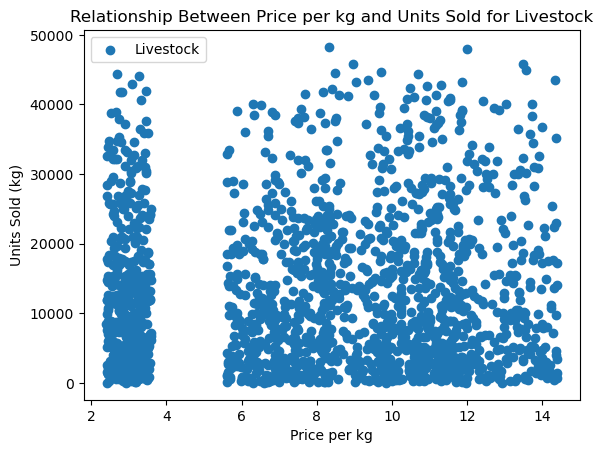

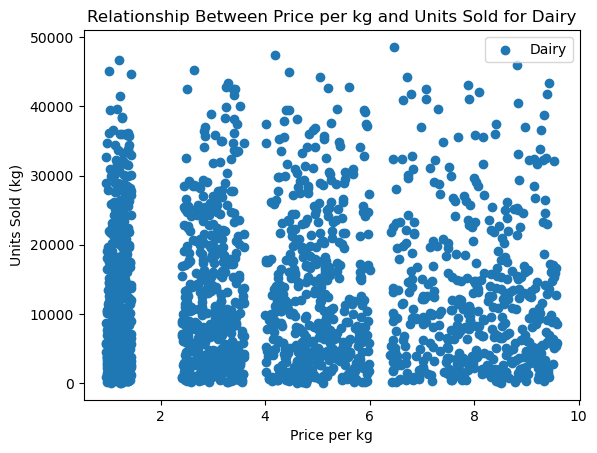

In [25]:
import matplotlib.pyplot as plt
import csv

def extract_price_units_data():
    price_sales_data = []
    shipping_sales_data = []
    
    with open('AgricultureData.csv', 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            price_per_kg = float(row['price_per_kg'] or 0)
            units_sold_kg = float(row['units_sold_kg'] or 0)
            units_shipped_kg = float(row['units_shipped_kg'] or 0)
            category = row['category']

            price_sales_data.append({
                'category': category,
                'price_per_kg': price_per_kg,
                'units_sold_kg': units_sold_kg
            })

            shipping_sales_data.append({
                'category': category,
                'units_sold_kg': units_sold_kg,
                'units_shipped_kg': units_shipped_kg
            })

    return price_sales_data, shipping_sales_data

price_sales_data, shipping_sales_data = extract_price_units_data()

category = 'Livestock'
category_data = [(d['price_per_kg'], d['units_sold_kg']) for d in price_sales_data if d['category'] == category]
if category_data:
    prices, units_sold = zip(*category_data)
    plt.scatter(prices, units_sold, label=category)
    plt.title(f'Relationship Between Price per kg and Units Sold for {category}')
    plt.xlabel('Price per kg')
    plt.ylabel('Units Sold (kg)')
    plt.legend()
    plt.show()

category = 'Dairy'
category_data = [(d['price_per_kg'], d['units_sold_kg']) for d in price_sales_data if d['category'] == category]
if category_data:
    prices, units_sold = zip(*category_data)
    plt.scatter(prices, units_sold, label=category)
    plt.title(f'Relationship Between Price per kg and Units Sold for {category}')
    plt.xlabel('Price per kg')
    plt.ylabel('Units Sold (kg)')
    plt.legend()
    plt.show()


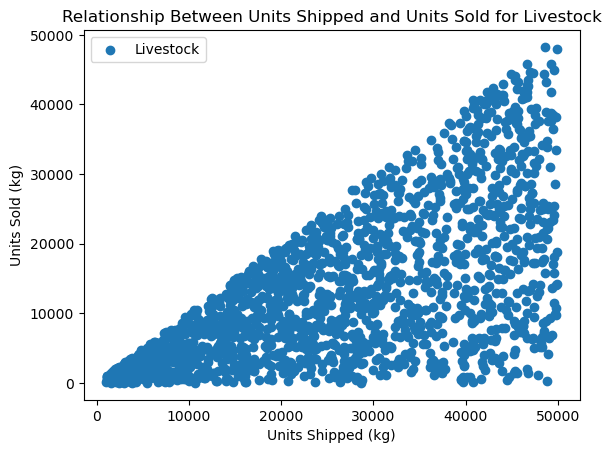

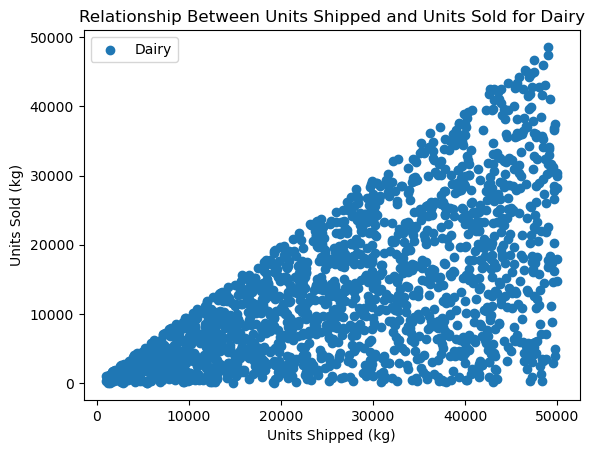

In [26]:
category = 'Livestock'
category_data = [(d['units_shipped_kg'], d['units_sold_kg']) for d in shipping_sales_data if d['category'] == category]
if category_data:
    units_shipped, units_sold = zip(*category_data)
    plt.scatter(units_shipped, units_sold, label=category)
    plt.title(f'Relationship Between Units Shipped and Units Sold for {category}')
    plt.xlabel('Units Shipped (kg)')
    plt.ylabel('Units Sold (kg)')
    plt.legend()
    plt.show()

category = 'Dairy'
category_data = [(d['units_shipped_kg'], d['units_sold_kg']) for d in shipping_sales_data if d['category'] == category]
if category_data:
    units_shipped, units_sold = zip(*category_data)
    plt.scatter(units_shipped, units_sold, label=category)
    plt.title(f'Relationship Between Units Shipped and Units Sold for {category}')
    plt.xlabel('Units Shipped (kg)')
    plt.ylabel('Units Sold (kg)')
    plt.legend()
    plt.show()

## Part 6 - Conclusion

TODO: write your conclusion here (interpret results of calculations; does it help answer your original questions?)

In [28]:
fruits_set = set()
vegetables_set = set()

for row in cleaned_data:
    category = row['category'].lower()
    product_name = row['product_name'].strip().lower()
    
    if category == 'fruit' or category == 'fruits':
        fruits_set.add(product_name)
    elif category == 'vegetable' or category == 'vegetables':
        vegetables_set.add(product_name)

num_fruits = len(fruits_set)
num_vegetables = len(vegetables_set)

print(f"Number of different kinds of fruits: {num_fruits}")
print(f"Fruits: {', '.join(fruits_set)}")

print(f"Number of different kinds of vegetables: {num_vegetables}")
print(f"Vegetables: {', '.join(vegetables_set)}")


Number of different kinds of fruits: 7
Fruits: bananas, apples, strawberries, grapes, blueberries, peaches, oranges
Number of different kinds of vegetables: 7
Vegetables: lettuce, cabbage, carrots, peppers, tomatoes, potatoes, onions


In [29]:
# TODO write code here!
import csv

us_states = {
    "AK": "Alaska",
    "AL": "Alabama",
    "AR": "Arkansas",
    "AZ": "Arizona",
    "CA": "California",
    "CO": "Colorado",
    "CT": "Connecticut",
    "DE": "Delaware",
    "FL": "Florida",
    "GA": "Georgia",
    "HI": "Hawaii",
    "IA": "Iowa",
    "ID": "Idaho",
    "IL": "Illinois",
    "IN": "Indiana",
    "KS": "Kansas",
    "KY": "Kentucky",
    "LA": "Louisiana",
    "MA": "Massachusetts",
    "MD": "Maryland",
    "ME": "Maine",
    "MI": "Michigan",
    "MN": "Minnesota",
    "MO": "Missouri",
    "MS": "Mississippi",
    "MT": "Montana",
    "NC": "North Carolina",
    "ND": "North Dakota",
    "NE": "Nebraska",
    "NH": "New Hampshire",
    "NJ": "New Jersey",
    "NM": "New Mexico",
    "NV": "Nevada",
    "NY": "New York",
    "OH": "Ohio",
    "OK": "Oklahoma",
    "OR": "Oregon",
    "PA": "Pennsylvania",
    "RI": "Rhode Island",
    "SC": "South Carolina",
    "SD": "South Dakota",
    "TN": "Tennessee",
    "TX": "Texas",
    "UT": "Utah",
    "VA": "Virginia",
    "VT": "Vermont",
    "WA": "Washington",
    "WI": "Wisconsin",
    "WV": "West Virginia",
    "WY": "Wyoming"
}
# The data is cited from 
# https://gist.github.com/JeffPaine/3083347

dairy_sales_by_state = {}

for row in cleaned_data:
    if row['category'] == 'Dairy':
        state_abbreviation = row['state']
        state_full_name = us_states.get(state_abbreviation, 'Unknown')
        
        try:
            units_sold = float(row['units_sold_kg'])
        except ValueError:
            units_sold = 0.0
        
        if state_full_name != 'Unknown':
            dairy_sales_by_state[state_full_name] = dairy_sales_by_state.get(state_full_name, 0) + units_sold

for state, total_sold in dairy_sales_by_state.items():
    print(f"{state}: {total_sold} kg")


Florida: 457214.0 kg
Colorado: 532347.0 kg
Texas: 561171.0 kg
Indiana: 328669.0 kg
Nevada: 484753.0 kg
Iowa: 559461.0 kg
Connecticut: 356163.0 kg
Wisconsin: 386015.0 kg
Maryland: 610867.0 kg
Rhode Island: 517803.0 kg
Washington: 658326.0 kg
Tennessee: 639921.0 kg
Michigan: 430819.0 kg
Pennsylvania: 567532.0 kg
Alaska: 290470.0 kg
Hawaii: 416762.0 kg
Alabama: 439747.0 kg
Minnesota: 520355.0 kg
Maine: 387984.0 kg
Delaware: 359340.0 kg
South Carolina: 541082.0 kg
Idaho: 595403.0 kg
New Jersey: 319939.0 kg
Illinois: 517074.0 kg
Vermont: 481999.0 kg
Missouri: 463060.0 kg
Oklahoma: 405876.0 kg
California: 471278.0 kg
Kentucky: 389404.0 kg
New York: 213581.0 kg
Georgia: 409934.0 kg
Wyoming: 507742.0 kg
Virginia: 453441.0 kg
Utah: 275094.0 kg
Montana: 451198.0 kg
South Dakota: 394984.0 kg
Arkansas: 441657.0 kg
New Hampshire: 576496.0 kg
Nebraska: 541833.0 kg
New Mexico: 384236.0 kg
Massachusetts: 372011.0 kg
Ohio: 432103.0 kg
Arizona: 497270.0 kg
Louisiana: 543841.0 kg
Oregon: 566632.0 kg
Nort

In [30]:
state_with_largest_sale = max(dairy_sales_by_state, key=dairy_sales_by_state.get)
largest_sale_amount = dairy_sales_by_state[state_with_largest_sale]

print(state_with_largest_sale)

Washington


In conclusion, both vegetables and fruits have the same number of types, with each having 7. Farms in Washington state sold the highest quantity of dairy products.

Correlation coefficient between height and weight: 0.7604621859407162


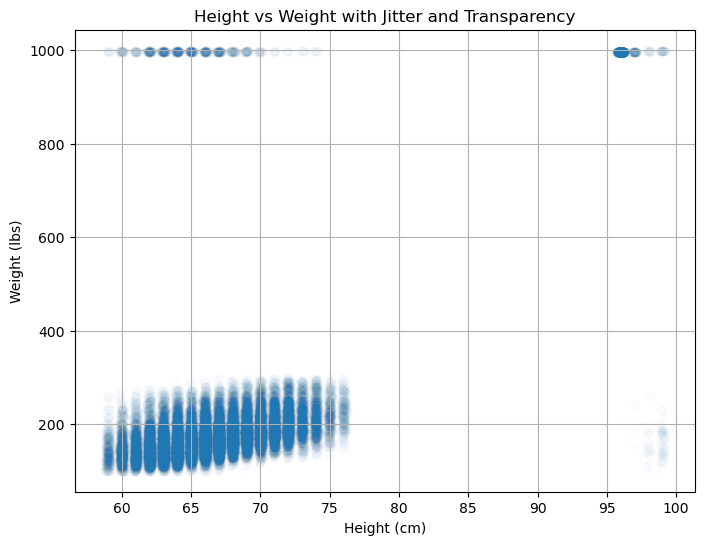

In [32]:
# I make the file in src since if I make it in raw,
# the file path does not work.
import csv
import numpy as np
import matplotlib.pyplot as plt
import random

heights = []
weights = []

with open('adult19.csv', 'r') as file:
    reader = csv.DictReader(file)
    for row in reader:
        height = row.get('HEIGHTTC_A')
        weight = row.get('WEIGHTLBTC_A')
        
        if height and weight:
            try:
                heights.append(float(height))
                weights.append(float(weight))
            except ValueError:
                continue  

heights = np.array(heights)
weights = np.array(weights)

corr_coef = np.corrcoef(heights, weights)[0, 1]
print(f"Correlation coefficient between height and weight: {corr_coef}")

def add_jitter(data, jitter_amount=0.1):
    return data + np.random.normal(0, jitter_amount, size=len(data))

heights_jittered = add_jitter(heights)
weights_jittered = add_jitter(weights)

plt.figure(figsize=(8, 6))
plt.scatter(heights_jittered, weights_jittered, alpha=0.01)
plt.title('Height vs Weight with Jitter and Transparency')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (lbs)')
plt.grid(True)

plt.show()
